**Notebook Feito por:** MSc. Eng. Paulo de Souza Silva  
**Data:** Agosto de 2026  
**Conteúdo retirado e adaptado de livros e artigos sobre Galerkin Descontínuo**  
**Agradecimentos:** Um agradecimento ao Prof. Dr. Alberto Nogueira pela disponibilização dos scripts em Python para DG 1D

# **Aula 07 - Superintegração e a Projeção de Fluxos**

## **Introdução**

Na aula anterior, enquanto construíamos a matriz de rigidez, fizemos manipulações a fim de separar o fluxo do problema e isolar o cálculo de $\mathcal{S}$. Nesta aula e na próxima, iremos entender como o reacoplamento do fluxo é feito de fato!

No encontro de hoje, vamos entender somente como recuperar o $f$ que acompanha a matriz de rigidez.

Na aula que vem, iremos conhecer diferentes estratégias de fluxo numérico para aplicarmos à nossa fronteira em conjunto com a função `LiftMatrix`



## **Problema da Não-Linearidade**

Até o momento, nossas matrizes foram construídas assumindo operações lineares. No entanto, leis de conservação são formadas, em sua maioria, por escoamentos não-lineares. 

Seja a Equação de Burgers Invíscida, cujo fluxo é $f(u) = \frac{u^2}{2}$, as Equações de Euler para dinâmica de gases ou o sistema de *Shallow Water*, a variável conservativa $u$ sofre produtos diretos. 

Se o nosso polinômio aproximador possui grau $N$, ao avaliarmos um fluxo como $u^2$, o resultado matemático passará a ter grau $2N$. Se tentarmos integrar esse fluxo "inchado" utilizando as matrizes de quadratura projetadas estritamente para o grau $N$, cometeremos o **Erro de Aliasing**. O conteúdo de alta frequência do polinômio de grau $2N$ será mapeado incorretamente para as baixas frequências do nosso espaço polinomial, o que invariavelmente destrói a estabilidade do solver DG. A solução para este problema é a **Projeção de Galerkin via Superintegração**.

Retomando de forma breve o que vimos no tema da aula 06, para o calculo da matriz de rigidez assumimos que:

$$f(u(\xi)) \approx \sum_{i=0}^{N} \hat{f}_i \phi_i (\xi)$$

e portanto

$$\int_{-1}^1 \sum_{j=0}^{N} \hat{f}_i \phi_i (\xi) \frac{d\phi_j(\xi)}{d\xi} d\xi \Longrightarrow  \sum_{i=0}^{N} \hat{f}_i \left( \int_{-1}^1 \phi_i (\xi) \frac{d\phi_j(\xi)}{d\xi} d\xi \right) = \sum_{i=0}^{N} \hat{f}_i \mathcal{S}_{ij}$$

Mas por que precisamos dessa aproximação do fluxo no somatório?

Para entender o problema, vamos imaginar um problema não-linear simples, onde o fluxo físico é dado por 
$$f(u) = \frac{u^2}{2}$$

Vamos supor que estamos trabalhando com um espaço restrito de grau $N=1$. Nossa solução $u(\xi)$ seria descrita por apenas dois termos:

$$u(\xi) = u_0 \phi_0(\xi) + u_1 \phi_1(\xi)$$

Se aplicarmos essa solução diretamente na função de fluxo físico $f(u)$, teremos:

$$f(u) = \frac{1}{2} \left( u_0 \phi_0(\xi) + u_1 \phi_1(\xi) \right)^2$$

$$f(u) = \frac{1}{2} \left( u_0^2 \phi_0^2(\xi) + 2 u_0 u_1 \phi_0(\xi) \phi_1(\xi) + u_1^2 \phi_1^2(\xi) \right)$$

**Note o que aconteceu:** como as nossas funções de base $\phi$ têm grau 1, ao serem multiplicadas entre si ($\phi^2$), o fluxo físico passou a ter grau 2 (ou seja, $2N$). Em problemas mais complexos, esse grau polinomial explode rapidamente! Isso implica em dois problemas:

> **Incompatibilidade Matricial**  
O fluxo resultante precisaria de $2N + 1$ coeficientes para ser representado, formando um vetor de tamanho $(2N+1)$. Se bem lembrarmos, nossas matrizes pré-calculadas (massa, rigidez, lift) são todas do tipo $(N+1) \times (N+1)$. Tentar multiplicar uma matriz $(N+1) \times (N+1)$ por um vetor de $(2N+1)$ posições simplesmente quebra a regra de multiplicação linear!

> **Aliasing**  
Se olharmos para a integral pura:  $$\int_{-1}^1 f(u(\xi)) \frac{d\phi_j(\xi)}{d\xi} d\xi$$  
Sabemos que $f(u)$, no nosso exemplo, tem grau $2N$ e a derivada da função de teste $\frac{d\phi_j}{d\xi}$ tem grau $N-1$. Isso significa que, se fôssemos calcular a integral exata do fluxo não-linear, estaríamos integrando um polinômio de grau $2N + (N - 1) = \mathbf{3N - 1}$.  
Os pontos de integração numérica (quadratura de Gauss) que escolhemos na construção do elemento foram dimensionados para integrar perfeitamente polinômios menores (geralmente até $2N-1$ ou $2N$). Se tentarmos forçar a integração de algo com grau $3N-1$ usando esses mesmos pontos, a matemática comete erros de arredondamento sistemáticos. Esse ruído numérico, chamado de erro de aliasing, se acumula e faz a simulação "explodir" em poucos passos de tempo.

Como a nossa matriz de rigidez $\mathcal{S}$ e o nosso elemento computacional foram construídos para suportar apenas polinômios até o grau $N$, nós não conseguimos representar esse fluxo de grau $2N$ de forma exata no nosso sistema.

---



### Projeção e Super-Integração

Por esse motivo precisamos forçar o fluxo físico de volta para o nosso espaço restrito de grau $N$. Definimos os coeficientes modais de fluxo projetado $\hat{f}_i$ tais que:

$$f(u_h) \approx \sum_{i=0}^{N} \hat{f}_i \phi_i(\xi)$$

Aplicando o formalismo de Galerkin, exigimos que o resíduo dessa aproximação seja ortogonal à nossa base $\phi_j$:

$$\int_{-1}^{1} \left( f(u_h) - \sum_{i} \hat{f}_i \phi_i \right) \phi_j d\xi = 0$$

Separando a soma da integral, recuperamos a **Matriz de Massa** ($\mathcal{M}_{ij}$):

$$\sum_{i} \underbrace{\left( \int_{-1}^{1} \phi_i \phi_j d\xi \right)}_{ \mathcal{M}_{ij} } \hat{f}_i = \underbrace{\int_{-1}^{1} f(u_h) \phi_j d\xi}_{ \mathbf{b}_j }$$

Em formato matricial, o sistema linear local é isolado da seguinte maneira:

$$\boxed{\hat{\mathbf{f}} = \mathcal{M}^{-1} \mathbf{b}}$$

A magia numérica ocorre na avaliação do vetor $\mathbf{b}$. Para evitar o erro de aliasing, nós podemos calcular a integral utilizando uma **quadratura de ordem superior** (*Over-integration*). Definimos graus exatos maiores, como $P_{nl} = 3N$, gerando novos pesos $w^{nl}_m$ e pontos $\xi^{nl}_m$.

$$\mathbf{b}_j = \sum_{m} w^{nl}_m f(u_h(\xi^{nl}_m)) \phi_j(\xi^{nl}_m)$$

E aqui temos duas coisas acontecendo aqui:
1. O índice $j$ (Testes): Ele representa as nossas funções de base $\phi_j$. Como estamos em um espaço de grau $N$, nós temos $N+1$ funções de base (de $\phi_0$ até $\phi_N$). É o índice $j$ que define quantas "linhas" o nosso vetor $\mathbf{b}$ vai ter.
2. O índice $m$ (Quadratura): Esse é o índice dos pontos de integração (que vai de $0$ até $3N$). Ele só existe dentro do somatório.

Isso significa que, para calcular uma única posição do vetor $\mathbf{b}$ (digamos, o $b_0$), você vai somar $3N$ termos. Mas no fim do somatório, tudo isso vira apenas um único número escalar.Se abrirmos o vetor $\mathbf{b}$, ele tem essa cara:

$$\mathbf{b} = \begin{bmatrix} b_0 \\ b_1 \\ \vdots \\ b_N \end{bmatrix} =  \begin{bmatrix} \sum_{m} w^{nl}_m f(u_h(\xi^{nl}_m)) \phi_0(\xi^{nl}_m) \\ \sum_{m} w^{nl}_m f(u_h(\xi^{nl}_m)) \phi_1(\xi^{nl}_m) \\ \vdots \\ \sum_{m} w^{nl}_m f(u_h(\xi^{nl}_m)) \phi_N(\xi^{nl}_m) \end{bmatrix}$$

Resumo das dimensões: 
* A matriz $\mathcal{M}^{-1}$ tem tamanho $(N+1) \times (N+1)$.
* O vetor $\mathbf{b}$ tem tamanho $(N+1) \times 1$.
* O resultado $\hat{\mathbf{f}}$ terá tamanho $(N+1) \times 1$.

Tudo se encaixa! A "mágica" da super-integração acontece de forma "escondida" dentro do cálculo de cada $b_j$. A matriz de massa $\mathcal{M}$ (que foi calculada lá no começo, com quadratura padrão) nem fica sabendo que usamos mais pontos para montar o $\mathbf{b}$.

## **Anatomia da Projeção no Código**

Ao analisarmos solvers para múltiplos problemas (Burgers, Shallow Water, Euler), nota-se que todos executam exatamente os mesmos quatro passos computacionais. É aqui que a matemática que acabamos de ver ganha vida no código:

1. **Recuperação (Espaço Modal $\rightarrow$ Espaço Físico):** 
Multiplicamos os coeficientes modais `uhat` pela matriz de base superintegrada `nlpsi` para encontrar a solução física `uh`.
> **Por que fazemos isso?** Nós conhecemos os coeficientes $\hat{u}$ da nossa solução, mas a função de fluxo não-linear exige o valor físico de $u$. Além disso, precisamos desse valor físico exatamente nos novos pontos da malha fina ($\xi^{nl}_m$) para realizar a super-integração. Matematicamente, estamos avaliando:
> $$u_h(\xi^{nl}_m) = \sum_{i=0}^{N} \hat{u}_i \phi_i(\xi^{nl}_m)$$

2. **A Física:** 
A avaliação não-linear ocorre exclusivamente nos pontos físicos através de uma chamada como `fh = Func(uh)`.
> **Por que fazemos isso?** Com os valores físicos recuperados nos pontos de quadratura superior, nós finalmente aplicamos a lei de conservação do problema real ponto a ponto. Se estivermos resolvendo a Equação de Burgers, por exemplo, o código simplesmente calcula:
> $$f(u_h(\xi^{nl}_m)) = \frac{(u_h(\xi^{nl}_m))^2}{2}$$

3. **Montagem de $\mathbf{b}$:** 
Integramos o resultado numericamente, o que em Python geralmente toma a forma de um produto matricial: `b = np.dot(nlwi * nlpsi.T, fh)`.
> **Por que fazemos isso?** Este passo é a execução direta da nossa técnica contra o erro de aliasing. Os pesos `nlwi` representam $w^{nl}_m$, e a matriz transposta `nlpsi.T` carrega os valores de $\phi_j(\xi^{nl}_m)$. A multiplicação matricial realiza exatamente o somatório da quadratura de ordem superior:
> $$\mathbf{b}_j = \sum_{m} w^{nl}_m f(u_h(\xi^{nl}_m)) \phi_j(\xi^{nl}_m)$$

4. **A Projeção (Espaço Físico $\rightarrow$ Espaço Modal):** 
Multiplicamos o vetor `b` pela matriz de massa inversa `InvM` para obter o fluxo final, pronto para uso no operador diferencial.
> **Por que fazemos isso?** O vetor $\mathbf{b}$ contém o resultado da integral exata, mas ainda não representa os coeficientes do nosso espaço polinomial. Para "espremer" esse vetor de volta aos nossos $N+1$ graus de liberdade (resolvendo a incompatibilidade matricial), aplicamos a solução do sistema linear local:
> $$\hat{\mathbf{f}} = \mathcal{M}^{-1} \mathbf{b}$$

> **Nota de Implementação: O Encapsulamento de `ut`**
> Para evitar erros comuns de manipulação de arrays e bugs difíceis de rastrear, nossa função solicita a matriz global `ut` inteira como argumento e cuida da extração dos dados internamente antes de iniciar o Passo 1, executando:
> ```python
> uhat = ut[:, 1:-1, 0].copy()
> ```
> Esse fatiamento prepara o algoritmo com segurança:
> * `[:]`: Pega todos os coeficientes modais (de $0$ a $N$).
> * `[1:-1]`: Extrai apenas os elementos internos do domínio, isolando e ignorando as condições de contorno (células fantasmas) nas bordas.
> * `[0]`: Seleciona a variável de estado de interesse.
> * `.copy()`: A peça mais importante! Garante que estamos manipulando uma cópia segura, evitando sobrescrever a solução do passo de tempo atual acidentalmente.

## **Codando: A Projeção Generalista**

No lugar de criarmos uma função `FluxProjection` diferente para cada física, podemos explorar o Python para encapsular a matemática da projeção, deixando o cálculo físico modular. 

Abaixo, construímos uma função que recebe uma lista de coeficientes (podem ser 1, 2 ou 3 equações acopladas) e uma função auxiliar `FluxFunc` que dita a física.

In [ ]:
import numpy as np
def FluxProjection(ut_list: list, FluxFunc: callable, nlpsi: np.ndarray, nlwi: np.ndarray, InvM: np.ndarray,):
    """
    Projeta o fluxo físico no espaço modal através de uma projeção L2.

    Esta implementação é genérica e suporta um número arbitrário de
    equações (Burgers, Euler, Navier-Stokes, etc.).

    Parâmetros
    ----------
    ut_list : list of ndarray
        Lista contendo as variáveis conservativas. Cada array deve possuir
        formato (Nldof, K+2) ou (Nldof, K+2, nstage).

    FluxFunc : callable
        Função responsável por calcular os fluxos físicos.

        Exemplos
        --------
        Burgers:
            FluxFunc(u) -> f

        Euler:
            FluxFunc(rho, rhou, E) -> (f1, f2, f3)

    nlpsi : ndarray
        Base modal avaliada nos pontos da quadratura de superintegração.

    nlwi : ndarray
        Pesos da quadratura de superintegração.

    InvM : ndarray
        Diagonal inversa da matriz de massa.

    Retorna
    -------
    ndarray ou list(ndarray)

        Burgers:
            fhat

        Sistemas:
            [fhat1, fhat2, ...]
    """

    # Remove células fantasmas (ghost cells)
    uhat_list = []

    for ut in ut_list:
        if ut.ndim == 3:
            uhat = ut[:, 1:-1, 0]
        elif ut.ndim == 2:
            uhat = ut[:, 1:-1]
        else:
            raise ValueError("Cada variável deve possuir dimensão 2 ou 3.")

        uhat_list.append(uhat)

    uh_list = [nlpsi @ uhat for uhat in uhat_list]   # Reconstrução da solução física
    fh_list = FluxFunc(*uh_list)   # Avaliação dos fluxos físicos

    # Burgers retorna apenas um array
    if not isinstance(fh_list, (list, tuple)):
        fh_list = [fh_list]

    # Verificação de consistência
    if len(fh_list) != len(uh_list):
        raise ValueError(
            f"FluxFunc retornou {len(fh_list)} fluxo(s), "
            f"mas existem {len(uh_list)} variável(is)."
        )

    # Projeção L2
    ProjectionMatrix = nlwi * nlpsi.T
    fhat_list = []

    for fh in fh_list:
        b = ProjectionMatrix @ fh
        fhat = (InvM * b.T).T
        fhat_list.append(fhat)

    # Compatibilidade com problemas escalares
    if len(fhat_list) == 1:
        return fhat_list[0]

    return fhat_list

### Como usar a Função Generalista?
Essa abordagem blindará o seu solver. Você nunca mais precisará alterar a projeção matemática. Toda vez que resolver um problema novo, bastará declarar as regras da física.

**Exemplo 1: Equação de Burgers Invíscida**

[-9.49107912e-01 -7.41531186e-01 -4.05845151e-01 -6.16297582e-33
  4.05845151e-01  7.41531186e-01  9.49107912e-01]


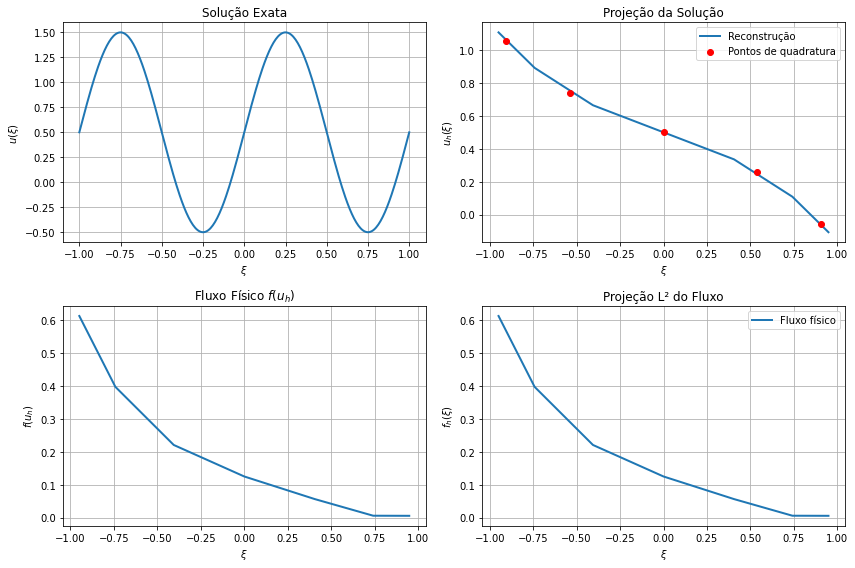

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from mathDG1D import *
from coreDG1D import *

# Grau de aproximação
N = 4
Nldof = N + 1

# Quadratura para projeção
xi, wi = jacobi_gauss_quad(
    P=2*N,
    alpha=0.0,
    beta=0.0,
    quad_type="GL"
)

psi = LegendreBasis(N, xi)

# Quadratura de superintegração
nlxi, nlwi = jacobi_gauss_quad(
    P=3*N,
    alpha=0.0,
    beta=0.0,
    quad_type="GL"
)
print(nlxi)
nlpsi = LegendreBasis(N, nlxi)

# Matriz de massa
_, InvM = MassMatrix(Nldof)

# Solução exata (avaliada em uma malha refinada)
xplot = np.linspace(-1, 1, 300)
u_exact = 0.5 + np.sin(2*np.pi*xplot)

# A mesma solução avaliada nos pontos da quadratura
u_quad = 0.5 + np.sin(2*np.pi*xi)

# Projeção L2 da solução
b = (wi * psi.T) @ u_quad
uhat = (InvM * b.T).T.reshape(-1,1)

# Reconstrução da solução
uh = nlpsi @ uhat

# Fluxo de Burgers
def BurgersFlux(u):
    return 0.5 * u**2

# Fluxo físico
fh = BurgersFlux(uh)

# Projeção do fluxo
fhat = FluxProjection(
    ut_list=[uhat],
    FluxFunc=BurgersFlux,
    nlpsi=nlpsi,
    nlwi=nlwi,
    InvM=InvM
)

# Reconstrução do fluxo projetado
fh_proj = nlpsi @ fhat

# Figura
fig, ax = plt.subplots(2, 2, figsize=(12,8))

# Solução exata
ax[0,0].plot(xplot, u_exact, lw=2)
ax[0,0].set_title("Solução Exata")
ax[0,0].set_xlabel(r"$\xi$")
ax[0,0].set_ylabel(r"$u(\xi)$")
ax[0,0].grid(True)

# Solução reconstruída
ax[0,1].plot(nlxi, uh, lw=2, label="Reconstrução")
ax[0,1].scatter(xi, u_quad, color="red", zorder=3, label="Pontos de quadratura")
ax[0,1].set_title("Projeção da Solução")
ax[0,1].set_xlabel(r"$\xi$")
ax[0,1].set_ylabel(r"$u_h(\xi)$")
ax[0,1].legend()
ax[0,1].grid(True)

# Fluxo físico
ax[1,0].plot(nlxi, fh, lw=2)
ax[1,0].set_title(r"Fluxo Físico $f(u_h)$")
ax[1,0].set_xlabel(r"$\xi$")
ax[1,0].set_ylabel(r"$f(u_h)$")
ax[1,0].grid(True)

# Fluxo projetado
ax[1,1].plot(nlxi, fh, lw=2, label="Fluxo físico")
ax[1,1].plot(nlxi, fh_proj, "--", lw=2, label="Fluxo projetado")
ax[1,1].set_title("Projeção L² do Fluxo")
ax[1,1].set_xlabel(r"$\xi$")
ax[1,1].set_ylabel(r"$f_h(\xi)$")
ax[1,1].legend()
ax[1,1].grid(True)

plt.tight_layout()
plt.show()

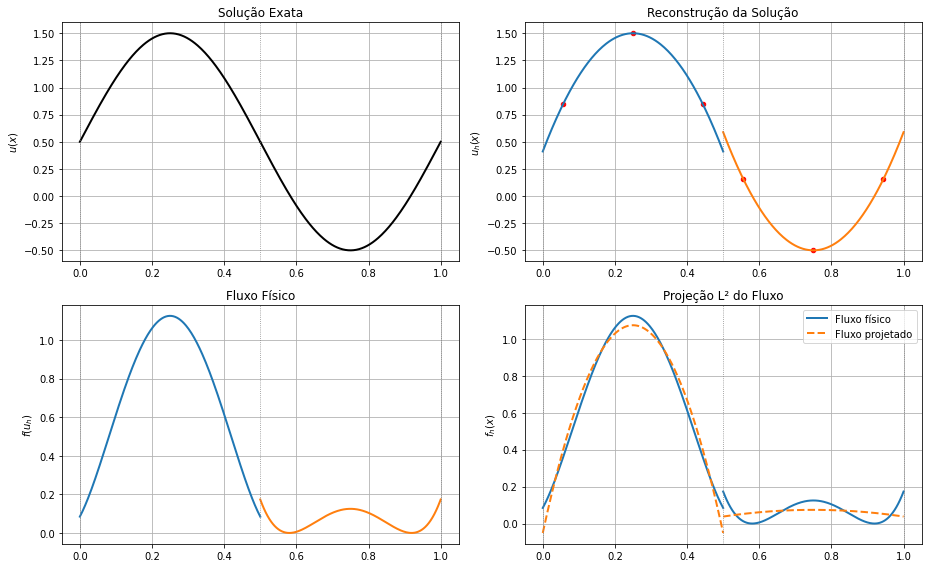

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from mathDG1D import *
from coreDG1D import *

# Grau do polinômio e número de elementos
N = 2
K = 2
Nldof = N + 1

# Malha
Nv, VX, EToV = MeshGen1D(K)

# Quadratura para projeção da condição inicial
xi, wi = jacobi_gauss_quad(P=2*N,alpha=0.0,beta=0.0,quad_type="GL")
psi = LegendreBasis(N, xi)

# Quadratura para superintegração
nlxi, nlwi = jacobi_gauss_quad(P=3*N,alpha=0.0,beta=0.0,quad_type="GL")
nlpsi = LegendreBasis(N, nlxi)

# Matriz de massa
_, InvM = MassMatrix(Nldof)

# Pontos apenas para visualização
xplot_ref = np.linspace(-1.0, 1.0, 200)
psi_plot = LegendreBasis(N, xplot_ref)

# Fluxo de Burgers
def BurgersFlux(u):
    return 0.5*u**2

# ----------------------------------------------------
# Projeta a condição inicial elemento por elemento
# ----------------------------------------------------

uhat = np.zeros((Nldof, K))

for k in range(K):

    xa = VX[k]
    xb = VX[k+1]

    # Pontos de quadratura no elemento físico
    x_quad = 0.5*(xb-xa)*xi + 0.5*(xa+xb)

    # Condição inicial
    u_quad = 0.5 + np.sin(2*np.pi*x_quad)

    # Projeção L²
    b = np.dot(wi*psi.T, u_quad)
    uhat[:,k] = InvM*b

# ----------------------------------------------------
# Monta ut exatamente como no solver
# ----------------------------------------------------

ut = np.zeros((Nldof, K+2, 1))

ut[:,1:-1,0] = uhat

# ----------------------------------------------------
# Projeção do fluxo (igual ao solver)
# ----------------------------------------------------

fhat = FluxProjection(
    ut_list=[ut],
    FluxFunc=BurgersFlux,
    nlpsi=nlpsi,
    nlwi=nlwi,
    InvM=InvM
)

# ----------------------------------------------------
# Plots
# ----------------------------------------------------

fig, ax = plt.subplots(2, 2, figsize=(13,8))

for k in range(K):

    xa = VX[k]
    xb = VX[k+1]

    # Domínio físico para visualização
    x_plot = 0.5*(xb-xa)*xplot_ref + 0.5*(xa+xb)

    # Pontos de quadratura
    x_quad = 0.5*(xb-xa)*xi + 0.5*(xa+xb)

    # Solução exata
    u_exact = 0.5 + np.sin(2*np.pi*x_plot)

    # Solução reconstruída
    uh = psi_plot @ uhat[:,k:k+1]

    # Fluxo físico
    fh = BurgersFlux(uh)

    # Fluxo projetado
    fh_proj = psi_plot @ fhat[:,k:k+1]

    # Solução exata
    ax[0,0].plot(x_plot, u_exact, color="black", lw=2)

    # Reconstrução
    ax[0,1].plot(x_plot, uh, lw=2)
    ax[0,1].scatter(x_quad,
                    0.5 + np.sin(2*np.pi*x_quad),
                    color="red",
                    s=20)

    # Fluxo físico
    ax[1,0].plot(x_plot, fh, lw=2)

    # Fluxo projetado
    ax[1,1].plot(
        x_plot,
        fh,
        color="tab:blue",
        lw=2,
        label="Fluxo físico" if k == 0 else None
    )

    ax[1,1].plot(
        x_plot,
        fh_proj,
        "--",
        color="tab:orange",
        lw=2,
        label="Fluxo projetado" if k == 0 else None
    )

# Desenha as interfaces dos elementos
for eixo in ax.ravel():

    for x in VX:
        eixo.axvline(x,
                     color="gray",
                     ls=":",
                     lw=0.8)

    eixo.grid(True)

ax[0,0].set_title("Solução Exata")
ax[0,1].set_title("Reconstrução da Solução")
ax[1,0].set_title("Fluxo Físico")
ax[1,1].set_title("Projeção L² do Fluxo")

ax[0,0].set_ylabel(r"$u(x)$")
ax[0,1].set_ylabel(r"$u_h(x)$")
ax[1,0].set_ylabel(r"$f(u_h)$")
ax[1,1].set_ylabel(r"$f_h(x)$")

ax[1,1].legend()

plt.tight_layout()
plt.show()

**Exemplo 2: Shallow Water (2 Equações Acopladas)**

In [ ]:
# A física do problema
def ShallowFlux(hh, uh):
    g = 9.81
    hf = hh * uh
    uf = g * hh + (uh**2) / 2.0
    return hf, uf

hhat_inner = ht[:, 1:-1, 0].copy()
uhat_inner = ut[:, 1:-1, 0].copy()

# A função generalista processa o sistema simultaneamente
hft_proj, uft_proj = FluxProjection([hhat_inner, uhat_inner], ShallowFlux, nlpsi, nlwi, InvM)